## Prove su RSS

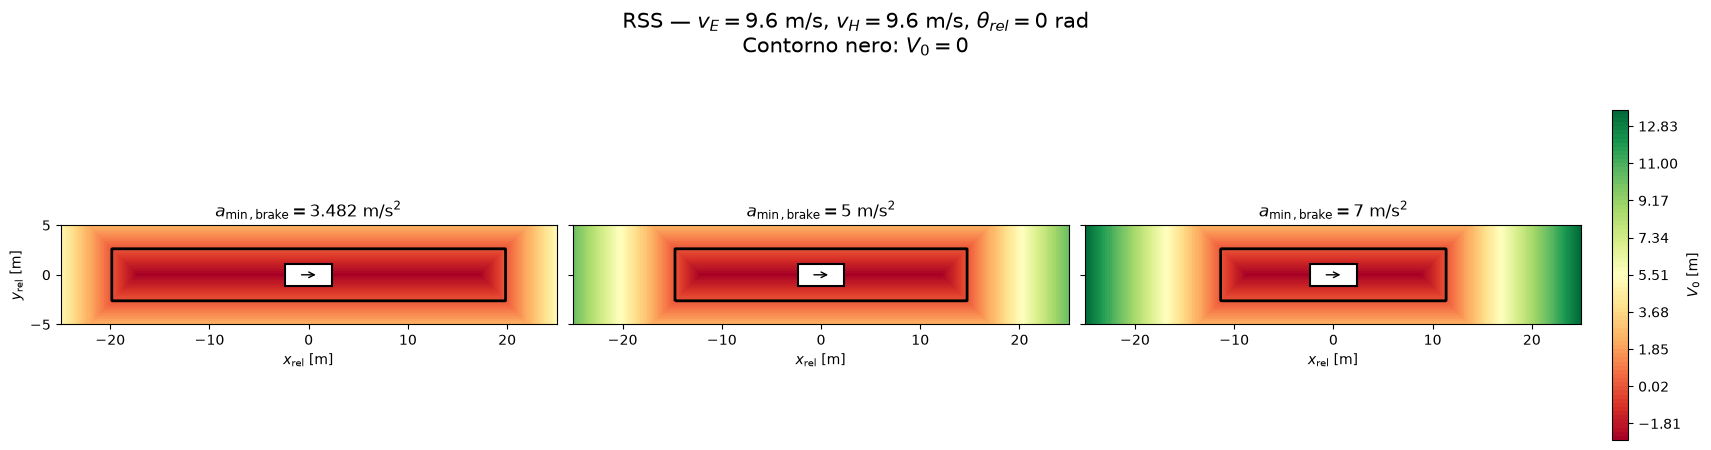

Confini longitudinali sulla linea y_rel = 0:
  b_min [m/s²]    x dietro [m]    x davanti [m]
         3.482          -19.84            19.84
         5.000          -14.72            14.72
         7.000          -11.36            11.36


In [1]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from hj_reachability.vehicle.metrics import metricRSS
from hj_reachability.vehicle.geometry.rectangles import (
    DEFAULT_EGO_GEOMETRY,
    DEFAULT_HUMAN_GEOMETRY,
)


# ---------------- CONFIGURAZIONE ----------------

V_E = 9.6                 # [m/s]
V_H = 9.6                 # [m/s]
THETA_REL = 0.0            # [rad]
DELTA_E = 0.0              # [rad]; V0 RSS è delta-invariante

BRAKING_VALUES = (3.482, 5.0, 7.0)  # [m/s²]

PARAMETERS = {
    "rho": 0.496,
    "mu": 0.20,
    "a_max_accel": 2.5,
    "a_max_brake": 7.0,
    "a_lat_max_accel": 0.68,
    "a_lat_min_brake": 0.45,
    "use_symmetry": True,
}

x = np.linspace(-25.0, 25.0, 501)
y = np.linspace(-5.0, 5.0, 201)


# ---------------- CALCOLO DELLA SOLA FETTA ----------------
# metricRSS usa soltanto coordinate_vectors e shape.
# Le dimensioni fissate contengono quindi un solo valore.
# Ordine: x_rel, y_rel, theta_rel, v_H, delta_E, v_E.

axes = (
    x,
    y,
    np.array([THETA_REL]),
    np.array([V_H]),
    np.array([DELTA_E]),
    np.array([V_E]),
)

slice_grid = SimpleNamespace(
    coordinate_vectors=axes,
    shape=tuple(axis.size for axis in axes),
)

slices = []
for braking in BRAKING_VALUES:
    result = metricRSS(
        grid=slice_grid,
        a_min_brake=braking,
        **PARAMETERS,
    )
    slices.append(result.terminal_values[:, :, 0, 0, 0, 0])


# ---------------- FIGURA ----------------
# Stessa scala cromatica per tutti i pannelli.
# Il contorno nero è V0 = 0; al suo interno V0 <= 0.

levels = np.linspace(
    min(float(values.min()) for values in slices),
    max(float(values.max()) for values in slices),
    81,
)

fig, axs = plt.subplots(
    1, len(BRAKING_VALUES),
    figsize=(17, 4.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

ego = DEFAULT_EGO_GEOMETRY

for ax, braking, values in zip(axs.ravel(), BRAKING_VALUES, slices):
    filled = ax.contourf(
        x, y, values.T,
        levels=levels,
        cmap="RdYlGn",
    )

    if values.min() < 0.0 < values.max():
        ax.contour(
            x, y, values.T,
            levels=[0.0],
            colors="black",
            linewidths=2,
        )

    ax.add_patch(Rectangle(
        (-ego.half_length, -ego.half_width),
        ego.length,
        ego.width,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    ))
    ax.annotate(
        "",
        xy=(1.0, 0.0),
        xytext=(-1.0, 0.0),
        arrowprops={"arrowstyle": "->", "color": "black"},
        zorder=6,
    )

    ax.set_title(
        rf"$a_{{\min,\mathrm{{brake}}}}={braking:g}\ \mathrm{{m/s^2}}$"
    )
    ax.set_xlabel(r"$x_{\mathrm{rel}}$ [m]")
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(y[0], y[-1])
    ax.set_aspect("equal", adjustable="box")

axs[0, 0].set_ylabel(r"$y_{\mathrm{rel}}$ [m]")

fig.colorbar(
    filled,
    ax=axs.ravel().tolist(),
    label=r"$V_0$ [m]",
    shrink=0.8,
    pad=0.02,
)

fig.suptitle(
    rf"RSS — $v_E={V_E:g}$ m/s, $v_H={V_H:g}$ m/s, "
    rf"$\theta_{{rel}}={THETA_REL:g}$ rad"
    "\nContorno nero: $V_0=0$",
    fontsize=15,
)

plt.show()


# ---------------- RISCONTRO NUMERICO ----------------
# Formula longitudinale per veicoli allineati nello stesso verso.

if np.isclose(np.sin(THETA_REL), 0.0) and np.cos(THETA_REL) > 0:
    rho = PARAMETERS["rho"]
    accel = PARAMETERS["a_max_accel"]
    b_max = PARAMETERS["a_max_brake"]
    half_lengths = (
        ego.half_length + DEFAULT_HUMAN_GEOMETRY.half_length
    )

    print("Confini longitudinali sulla linea y_rel = 0:")
    print(
        f"{'b_min [m/s²]':>14} "
        f"{'x dietro [m]':>15} "
        f"{'x davanti [m]':>16}"
    )

    for braking in BRAKING_VALUES:
        safe_front = max(
            V_E * rho + 0.5 * accel * rho**2
            + (V_E + accel * rho)**2 / (2 * braking)
            - V_H**2 / (2 * b_max),
            0.0,
        )
        safe_behind = max(
            V_H * rho + 0.5 * accel * rho**2
            + (V_H + accel * rho)**2 / (2 * braking)
            - V_E**2 / (2 * b_max),
            0.0,
        )

        print(
            f"{braking:14.3f} "
            f"{-(half_lengths + safe_behind):15.2f} "
            f"{half_lengths + safe_front:16.2f}"
        )